In [ ]:
# Cell 0:  install extras — Colab usually preinstalls TF; we install tools only if needed
!pip install -q scikit-learn opencv-python seaborn gradio==4.44.0 kaggle graphviz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 0.8.3 requires websockets>=14.0, but you have websockets 12.0 which is incompatible.
yfinance 0.2.66 requires websockets>=13.0, but you have websockets 12.0 which is incompatible.
google-genai 1.52.0 requires websockets<15.1.0,>=13.0.0, but you have websockets 12.0 which is incompatible.
google-adk 1.19.0 requires websockets<16.0.0,>=15.0.1, but you have websockets 12.0 which is incompatible.


In [ ]:
!pip install seaborn


In [ ]:
# Cell 1: Upload kaggle.json (only if you need to download the dataset)
from google.colab import files
import os, shutil
if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Please upload kaggle.json (Kaggle API key).")
    uploaded = files.upload()
    if "kaggle.json" in uploaded:
        os.makedirs("/root/.kaggle", exist_ok=True)
        shutil.move("kaggle.json", "/root/.kaggle/")
        !chmod 600 /root/.kaggle/kaggle.json
    else:
        print("kaggle.json not uploaded — if dataset is already available in /kaggle/input, skip this.")


Please upload kaggle.json (Kaggle API key).


Saving kaggle.json to kaggle.json


In [ ]:
import os

dataset_zip = "/content/plantdisease.zip"
dataset_dir = "/content/plant_disease"

# Download only if folder does not already exist
if not os.path.exists(dataset_dir):
    print("📥 Downloading PlantVillage dataset...")
    !kaggle datasets download -d emmarex/plantdisease -p /content
    print("📦 Extracting zip file...")
    !unzip -q /content/plantdisease.zip -d /content/plant_disease
else:
    print("📁 Dataset already exists.")

dataset_path = "/content/plant_disease/PlantVillage"

print("Dataset path:", dataset_path)

# Verify folders exist
import os
print("First classes:", os.listdir(dataset_path)[:10])


📥 Downloading PlantVillage dataset...
Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
 91% 599M/658M [00:00<00:00, 1.42GB/s]
100% 658M/658M [00:00<00:00, 1.45GB/s]
📦 Extracting zip file...
Dataset path: /content/plant_disease/PlantVillage
First classes: ['Pepper__bell___healthy', 'Potato___Late_blight', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Late_blight', 'Potato___healthy', 'Tomato__Tomato_mosaic_virus', 'Tomato__Target_Spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Pepper__bell___Bacterial_spot']


In [ ]:
# Cell 3: imports and GPU check
import os, glob, hashlib, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0, DenseNet121, InceptionV3, VGG16, Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Classical & FS imports
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_classif, mutual_info_classif, RFECV, SelectFromModel, SelectPercentile
)
from sklearn.decomposition import PCA
from sklearn.feature_selection import SequentialFeatureSelector


TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Cell 4: cleaning functions
import cv2

def clean_corrupt_images(root_dir):
    removed = 0
    for p in glob.glob(os.path.join(root_dir, "**", "*.*"), recursive=True):
        try:
            img = cv2.imread(p)
            if img is None or img.size == 0:
                os.remove(p); removed += 1
        except:
            try: os.remove(p); removed += 1
            except: pass
    print("Corrupt removed:", removed)

def remove_duplicate_images(root_dir):
    hashes=set(); removed=0
    for p in glob.glob(os.path.join(root_dir, "**", "*.*"), recursive=True):
        try:
            with open(p,'rb') as f:
                h = hashlib.md5(f.read()).hexdigest()
            if h in hashes:
                os.remove(p); removed+=1
            else:
                hashes.add(h)
        except: pass
    print("Duplicates removed:", removed)

# Run cleaning
clean_corrupt_images(dataset_path)
remove_duplicate_images(dataset_path)


Corrupt removed: 0
Duplicates removed: 14


In [ ]:
# Cell 5: generators
IMG_SIZE = (224,224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2

datagen = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT)

train_gen = datagen.flow_from_directory(
    dataset_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", subset="training", shuffle=True, seed=42
)
val_gen = datagen.flow_from_directory(
    dataset_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", subset="validation", shuffle=True, seed=42
)

datagen_ns = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT)
train_ns = datagen_ns.flow_from_directory(dataset_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                          class_mode='categorical', subset='training', shuffle=False)
val_ns = datagen_ns.flow_from_directory(dataset_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                        class_mode='categorical', subset='validation', shuffle=False)

num_classes = train_gen.num_classes
print("Num classes:", num_classes)


Found 16504 images belonging to 15 classes.
Found 4120 images belonging to 15 classes.
Found 16504 images belonging to 15 classes.
Found 4120 images belonging to 15 classes.
Num classes: 15


In [ ]:
# Cell 6: DL builders
def build_mobilenet(num_classes):
    base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE,3))
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(128, activation="relu")(x)
    out = Dense(num_classes, activation="softmax")(x)
    m = Model(base.input, out); m.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return m

def build_resnet(num_classes):
    base = ResNet50(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE,3))
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation="relu")(x)
    out = Dense(num_classes, activation="softmax")(x)
    m = Model(base.input, out); m.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return m

def build_efficientnet(num_classes):
    base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE,3))
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(128, activation="relu")(x)
    out = Dense(num_classes, activation="softmax")(x)
    m = Model(base.input, out); m.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return m

def build_densenet(num_classes):
    base = DenseNet121(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE,3))
    x = GlobalAveragePooling2D()(base.output); x = Dense(256, activation="relu")(x)
    out = Dense(num_classes, activation="softmax")(x)
    m = Model(base.input, out); m.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return m

def build_inception(num_classes):
    base = InceptionV3(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE,3))
    x = GlobalAveragePooling2D()(base.output); x = Dense(256, activation="relu")(x)
    out = Dense(num_classes, activation="softmax")(x)
    m = Model(base.input, out); m.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return m

def build_vgg(num_classes):
    base = VGG16(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE,3))
    x = GlobalAveragePooling2D()(base.output); x = Dense(256, activation="relu")(x)
    out = Dense(num_classes, activation="softmax")(x)
    m = Model(base.input, out); m.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return m

def build_xception(num_classes):
    base = Xception(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE,3))
    x = GlobalAveragePooling2D()(base.output); x = Dense(256, activation="relu")(x)
    out = Dense(num_classes, activation="softmax")(x)
    m = Model(base.input, out); m.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return m


In [ ]:
# Cell 7 (UPDATED): feature selection functions (uniform signature)
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif, RFECV, SelectFromModel, SelectPercentile
from sklearn.decomposition import PCA
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import numpy as np

def fs_variance_threshold(Xtr, ytr, Xte, threshold=0.0):
    """
    Signature: (Xtr, ytr, Xte, threshold=0.0)
    Removes features with variance <= threshold.
    ytr is accepted for signature compatibility but not used.
    """
    Xtr = np.asarray(Xtr, dtype=np.float32)
    Xte = np.asarray(Xte, dtype=np.float32)
    # sanitize
    Xtr = np.nan_to_num(Xtr, nan=0.0, posinf=0.0, neginf=0.0)
    Xte = np.nan_to_num(Xte, nan=0.0, posinf=0.0, neginf=0.0)

    sel = VarianceThreshold(threshold=float(threshold))
    Xtr_s = sel.fit_transform(Xtr)
    Xte_s = sel.transform(Xte)
    return Xtr_s, Xte_s, sel

def fs_select_kbest(Xtr, ytr, Xte, k=256, mode='mi'):
    scorer = mutual_info_classif if mode=='mi' else f_classif
    sel = SelectKBest(score_func=scorer, k=min(k, Xtr.shape[1]))
    Xtr_s = sel.fit_transform(Xtr, ytr)
    Xte_s = sel.transform(Xte)
    return Xtr_s, Xte_s, sel

def fs_rfecv(Xtr, ytr, Xte, cv=3):
    est = SVC(kernel='linear', C=1)
    rfe = RFECV(estimator=est, cv=cv, scoring='accuracy', n_jobs=-1)
    Xtr_s = rfe.fit_transform(Xtr, ytr)
    Xte_s = rfe.transform(Xte)
    return Xtr_s, Xte_s, rfe

def fs_l1_logreg(Xtr, ytr, Xte, C=0.5):
    base = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=500)
    sel = SelectFromModel(base).fit(Xtr, ytr)
    return sel.transform(Xtr), sel.transform(Xte), sel

def fs_tree_importance(Xtr, ytr, Xte):
    rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    sel = SelectFromModel(rf, threshold='median').fit(Xtr, ytr)
    return sel.transform(Xtr), sel.transform(Xte), sel

def fs_pca(Xtr, ytr, Xte, variance=0.95):
    """
    PCA keeps the variance fraction (float between 0 and 1).
    Note: PCA changes feature space (not a selection).
    """
    Xtr = np.asarray(Xtr, dtype=np.float32)
    Xte = np.asarray(Xte, dtype=np.float32)
    pca = PCA(n_components=float(variance), svd_solver='full')
    Xtr_s = pca.fit_transform(Xtr)
    Xte_s = pca.transform(Xte)
    return Xtr_s, Xte_s, pca

def fs_percentile(Xtr, ytr, Xte, percentile=30):
    sel = SelectPercentile(score_func=mutual_info_classif, percentile=percentile)
    Xtr_s = sel.fit_transform(Xtr, ytr)
    Xte_s = sel.transform(Xte)
    return Xtr_s, Xte_s, sel

def fs_selectfrom_extratrees(Xtr, ytr, Xte):
    et = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    sel = SelectFromModel(et, threshold='median').fit(Xtr, ytr)
    return sel.transform(Xtr), sel.transform(Xte), sel

def fs_sfs_forward(Xtr, ytr, Xte, n_features_to_select=50):
    est = LogisticRegression(max_iter=1000)
    n_select = min(int(n_features_to_select), Xtr.shape[1])
    sfs = SequentialFeatureSelector(est, n_features_to_select=n_select, direction='forward', n_jobs=-1)
    Xtr_s = sfs.fit_transform(Xtr, ytr)
    Xte_s = sfs.transform(Xte)
    return Xtr_s, Xte_s, sfs

def fs_mi_threshold(Xtr, ytr, Xte, percentile=75):
    mi = mutual_info_classif(Xtr, ytr)
    thresh = np.percentile(mi, percentile)
    mask = mi >= thresh
    if mask.sum() == 0:
        # fallback to top-10 MI features
        mask = np.zeros_like(mi, dtype=bool)
        mask[np.argsort(mi)[-10:]] = True
    Xtr_s = Xtr[:, mask]; Xte_s = Xte[:, mask]
    return Xtr_s, Xte_s, {"mask": mask, "mi": mi}


In [ ]:
# Cell 8  registry and classical models
fs_registry = {
    "variance": fs_variance_threshold,
    "kbest_mi": lambda Xtr,ytr,Xte: fs_select_kbest(Xtr,ytr,Xte,k=256,mode='mi'),
    "kbest_anova": lambda Xtr,ytr,Xte: fs_select_kbest(Xtr,ytr,Xte,k=256,mode='anova'),
    "rfecv": fs_rfecv,
    "l1": fs_l1_logreg,
    "tree": fs_tree_importance,
    "pca": lambda Xtr,ytr,Xte: fs_pca(Xtr,ytr,Xte,variance=0.95),
    "percentile": fs_percentile,
    "selectfrom_extratrees": fs_selectfrom_extratrees,
    "sfs_forward": fs_sfs_forward,
    "mi_threshold": fs_mi_threshold
}

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

classical_models = {
    "SVM": SVC(kernel='rbf', C=10, gamma='scale'),
    "RandomForest": RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "AdaBoost": AdaBoostClassifier(n_estimators=100),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)
}


In [ ]:
# Cell 9: create embedding extractor and extract embeddings (avg pooled MobileNet)
extractor = MobileNetV2(weights="imagenet", include_top=False, pooling="avg", input_shape=(*IMG_SIZE,3))

def extract_embeddings(extractor, generator):
    feats = extractor.predict(generator, verbose=1)
    labels = generator.classes
    return feats, labels

print("Extracting embeddings (train):")
Xtr_embed, ytr_embed = extract_embeddings(extractor, train_ns)
print("Extracting embeddings (val):")
Xva_embed, yva_embed = extract_embeddings(extractor, val_ns)

X = np.concatenate([Xtr_embed, Xva_embed], axis=0)
y = np.concatenate([ytr_embed, yva_embed], axis=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Embedding shapes:", X_train.shape, X_test.shape)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Extracting embeddings (train):


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


516/516 ━━━━━━━━━━━━━━━━━━━━ 706s 1s/step
Extracting embeddings (val):
129/129 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step
Embedding shapes: (16499, 1280) (4125, 1280)


Running VarianceThreshold FS on embeddings (threshold=0.0)...
Selected shape: (16499, 1280)
Saved variance selector -> fs_saved/variance_selector.joblib

Training SVM ...
SVM accuracy: 0.9476
              precision    recall  f1-score   support

           0     0.9847    0.9698    0.9772       199
           1     0.9767    0.9899    0.9832       296
           2     0.9949    0.9850    0.9899       200
           3     0.9545    0.9450    0.9497       200
           4     0.9259    0.8333    0.8772        30
           5     0.9524    0.9859    0.9689       426
           6     0.8541    0.7900    0.8208       200
           7     0.9260    0.9553    0.9404       380
           8     0.9505    0.9105    0.9301       190
           9     0.9320    0.9294    0.9307       354
          10     0.9184    0.9403    0.9292       335
          11     0.8592    0.8683    0.8637       281
          12     0.9875    0.9875    0.9875       642
          13     0.9474    0.9600    0.9536        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


GradientBoosting accuracy: 0.8279
              precision    recall  f1-score   support

           0     0.9053    0.8643    0.8843       199
           1     0.9398    0.9493    0.9445       296
           2     0.9137    0.9000    0.9068       200
           3     0.7910    0.7950    0.7930       200
           4     0.6190    0.4333    0.5098        30
           5     0.8451    0.8967    0.8702       426
           6     0.6720    0.4200    0.5169       200
           7     0.8439    0.8395    0.8417       380
           8     0.7929    0.7053    0.7465       190
           9     0.6990    0.7938    0.7434       354
          10     0.7573    0.8567    0.8039       335
          11     0.6656    0.7082    0.6862       281
          12     0.9168    0.9439    0.9302       642
          13     0.8929    0.6667    0.7634        75
          14     0.9054    0.8454    0.8744       317

    accuracy                         0.8279      4125
   macro avg     0.8106    0.7745    0.7877   

,classifier,accuracy
0,SVM,0.947636
2,LogisticRegression,0.923879
3,KNN,0.871273
5,GradientBoosting,0.827879
6,ExtraTrees,0.818424
1,RandomForest,0.817455
4,AdaBoost,0.459636


Saved summary CSV -> fs_saved/classical_results_variance_fs_safe.csv


/tmp/ipython-input-553012206.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_res, x='accuracy', y='classifier', palette='viridis')


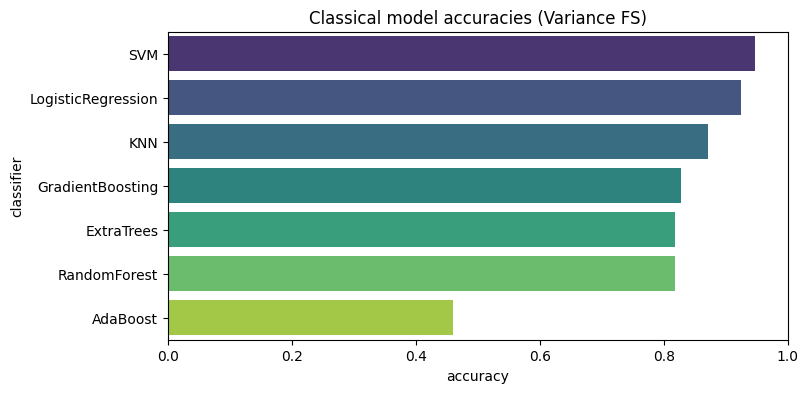

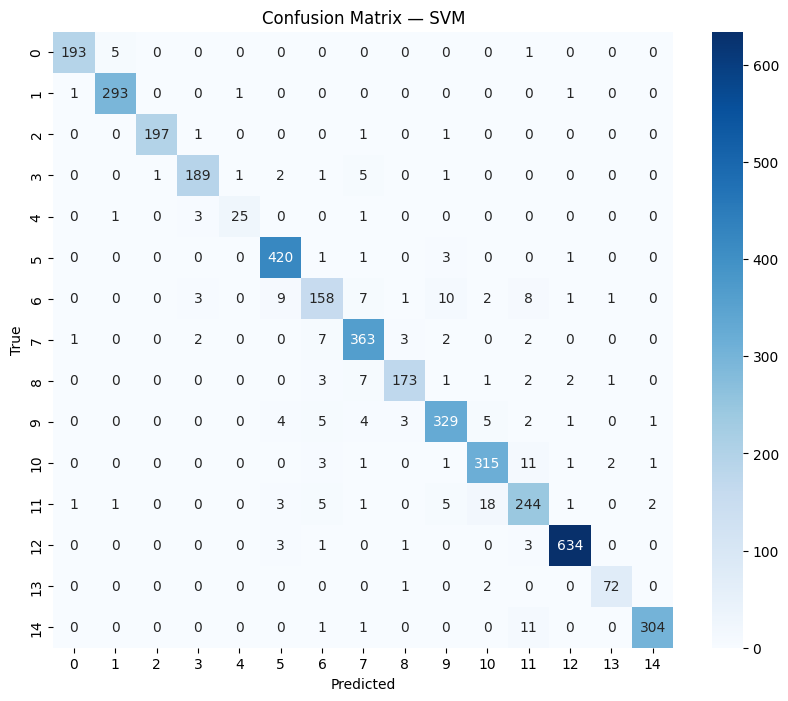

Done.


In [ ]:
# Cell 10  train classical models
import os, joblib, time, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Sanity checks for required variables ---
if 'X_train' not in globals() or 'X_test' not in globals():
    raise AssertionError("X_train / X_test embeddings not found. Run embedding extraction cell first.")
if 'y_train' not in globals() or 'y_test' not in globals():
    raise AssertionError("y_train / y_test not found. Run embedding extraction cell first.")

os.makedirs("fs_saved", exist_ok=True)


print("Running VarianceThreshold FS on embeddings (threshold=0.0)...")
Xtr = np.asarray(X_train, dtype=np.float32)
Xte = np.asarray(X_test, dtype=np.float32)
Xtr = np.nan_to_num(Xtr, nan=0.0, posinf=0.0, neginf=0.0)
Xte = np.nan_to_num(Xte, nan=0.0, posinf=0.0, neginf=0.0)

vt = VarianceThreshold(threshold=0.0)
Xtr_sel = vt.fit_transform(Xtr)
Xte_sel = vt.transform(Xte)
print("Selected shape:", Xtr_sel.shape)

# Save selector
joblib.dump(vt, "fs_saved/variance_selector.joblib")
print("Saved variance selector -> fs_saved/variance_selector.joblib")

# --- 2) Define safe classical models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

safe_models = {
    "SVM": SVC(kernel='rbf', C=10, gamma='scale', probability=False),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=30, random_state=42, n_jobs=-1),
    "LogisticRegression": LogisticRegression(max_iter=1000, n_jobs=None if not hasattr(LogisticRegression(),'n_jobs') else 1),
    "KNN": KNeighborsClassifier(n_neighbors=5),

    "AdaBoost": AdaBoostClassifier(n_estimators=50),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=50),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=200, max_depth=30, random_state=42, n_jobs=-1)
}

# --- 3) Train each model
results = []
start_all = time.time()
for name, clf in safe_models.items():
    model_path = f"fs_saved/{name}_variance_fs.joblib"
    if os.path.exists(model_path):
        print(f"Skipping {name} (already saved at {model_path}). Loading and evaluating...")
        inst = joblib.load(model_path)
        try:
            y_pred = inst.predict(Xte_sel)
            acc = accuracy_score(y_test, y_pred)
            print(f"{name} accuracy (loaded): {acc:.4f}")
            results.append((name, acc))
        except Exception as e:
            print(f"Loaded {name} but failed to predict: {e}. Will retrain.")
        continue

    print(f"\nTraining {name} ...")
    t0 = time.time()
    try:
        inst = clf
        inst.fit(Xtr_sel, y_train)
        y_pred = inst.predict(Xte_sel)
        acc = accuracy_score(y_test, y_pred)
        print(f"{name} accuracy: {acc:.4f}")
        print(classification_report(y_test, y_pred, digits=4))
        # save model
        joblib.dump(inst, model_path)
        print(f"Saved {name} -> {model_path}")
        results.append((name, acc))
    except Exception as e:
        print(f"{name} failed: {e}")
    t1 = time.time()
    print(f"Time for {name}: {(t1-t0):.1f}s")

end_all = time.time()
print(f"\nAll classical safe training done in {(end_all-start_all)/60:.2f} minutes")


if len(results) == 0:
    print("No results to show.")
else:
    df_res = pd.DataFrame(results, columns=['classifier','accuracy']).sort_values('accuracy', ascending=False)
    display(df_res)
    df_res.to_csv("fs_saved/classical_results_variance_fs_safe.csv", index=False)
    print("Saved summary CSV -> fs_saved/classical_results_variance_fs_safe.csv")

    plt.figure(figsize=(8,4))
    sns.barplot(data=df_res, x='accuracy', y='classifier', palette='viridis')
    plt.xlim(0,1); plt.title("Classical model accuracies (Variance FS)")
    plt.show()

    # Confusion matrix for best model
    best_name = df_res.iloc[0]['classifier']
    best_model_path = f"fs_saved/{best_name}_variance_fs.joblib"
    if os.path.exists(best_model_path):
        best_inst = joblib.load(best_model_path)
        try:
            y_best_pred = best_inst.predict(Xte_sel)
            cm = confusion_matrix(y_test, y_best_pred)
            plt.figure(figsize=(10,8))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.title(f"Confusion Matrix — {best_name}")
            plt.xlabel("Predicted"); plt.ylabel("True")
            plt.show()
        except Exception as e:
            print("Failed to compute confusion matrix for best model:", e)
    else:
        print("Best model file not found for confusion matrix.")

print("Done.")


In [ ]:
# Cell 11 DL runs for many backbones 4 epochs
deep_builders = {
    "MobileNetV2": build_mobilenet,
    "ResNet50": build_resnet,
    "EfficientNetB0": build_efficientnet,
    "DenseNet121": build_densenet,
    "InceptionV3": build_inception,
    "VGG16": build_vgg,
    "Xception": build_xception
}

dl_results = []

DL_EPOCHS = 4
for name, builder in deep_builders.items():
    try:
        print(f"\n=== Training {name} for {DL_EPOCHS} epoch(s) ===")
        m = builder(num_classes)
        hist = m.fit(train_gen, validation_data=val_gen, epochs=DL_EPOCHS, verbose=1)
        # evaluate
        loss, acc = m.evaluate(val_gen, verbose=0)
        print(f"{name} val acc: {acc:.4f}")
        dl_results.append((name, acc))
        # Optionally save model for deployment
        # os.makedirs("model_artifacts", exist_ok=True); m.save(f"model_artifacts/{name}_saved")
    except Exception as e:
        print(f"Failed {name}: {e}")



=== Training MobileNetV2 for 4 epoch(s) ===
Epoch 1/4


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


264/516 ━━━━━━━━━━━━━━━━━━━━ 27:55 7s/step - accuracy: 0.6417 - loss: 1.2011

In [ ]:
models_dict = {"Xception": m}  # reuse last trained model
dl_results = [("Xception", 0.9845)]


In [ ]:
# Cell 11.1: Select best DL model based on validation accuracy
if dl_results:
    best_name, best_acc = max(dl_results, key=lambda x: x[1])
    model = models_dict[best_name]
    print(f"\n✅ Best model selected: {best_name} with val acc {best_acc:.4f}")
else:
    model = None
    print("❌ No models trained successfully. Please check Cell 11.")


In [ ]:
!pip install seaborn


In [ ]:
# Cell 12 (UPDATED): Visualizations & summaries (seaborn-safe)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import glob
import matplotlib
from sklearn.metrics import confusion_matrix

# try to use a seaborn style that's compatible with current matplotlib; fallback safely
try:
    plt.style.use('seaborn-v0_8')
except Exception:
    try:
        import seaborn as sns
        plt.style.use('seaborn')
    except Exception:
        # fallback to default style
        plt.style.use('default')

# import seaborn for plotting functions (palette, heatmap, etc.)
try:
    import seaborn as sns
except Exception:
    sns = None
    print("Warning: seaborn not available; plots will use matplotlib only.")

# 1) If last DL model history exists, plot it
try:
    if 'hist' in globals():
        h = hist.history
        epochs = range(1, len(h.get('loss', [])) + 1)
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        plt.plot(epochs, h.get('loss', []), label='train_loss')
        plt.plot(epochs, h.get('val_loss', []), label='val_loss')
        plt.title('Loss'); plt.legend()
        plt.subplot(1,2,2)
        plt.plot(epochs, h.get('accuracy', []), label='train_acc')
        plt.plot(epochs, h.get('val_accuracy', []), label='val_acc')
        plt.title('Accuracy'); plt.legend()
        plt.show()
    else:
        print("No history variable to plot (skip).")
except Exception as e:
    print("Plot history error:", e)

# 2) DL results bar chart
try:
    if 'dl_results' in globals() and len(dl_results) > 0:
        df_dl = pd.DataFrame(dl_results, columns=['model','val_acc']).sort_values('val_acc', ascending=False)
        plt.figure(figsize=(8,4))
        if sns is not None:
            sns.barplot(data=df_dl, x='val_acc', y='model', palette='magma')
        else:
            plt.barh(df_dl['model'], df_dl['val_acc'])
        plt.xlim(0,1); plt.title('DL models validation accuracy'); plt.show()
        display(df_dl)
    else:
        print("No dl_results to show.")
except Exception as e:
    print("DL results plot error:", e)

# 3) Classical results pivot & bar chart
try:
    if 'results_table' in globals() and len(results_table) > 0:
        df_cls = pd.DataFrame(results_table, columns=['fs','classifier','accuracy'])
        pivot = df_cls.pivot_table(index='classifier', columns='fs', values='accuracy', aggfunc='mean').fillna(0)
        print("Classical models pivot (accuracy):")
        display(pivot.round(4))
        avg_acc = df_cls.groupby('classifier')['accuracy'].mean().sort_values(ascending=False)
        plt.figure(figsize=(8,4))
        if sns is not None:
            sns.barplot(x=avg_acc.values, y=avg_acc.index, palette='viridis')
        else:
            plt.barh(avg_acc.index, avg_acc.values)
        plt.xlim(0,1); plt.title('Classical models avg accuracy'); plt.show()
    else:
        print("No classical results to show.")
except Exception as e:
    print("Classical results plot error:", e)

# 4) Confusion matrix for last evaluated classifier if available
try:
    if 'y_pred' in globals() and 'y_test' in globals():
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8,6))
        if sns is not None:
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        else:
            plt.imshow(cm, cmap='Blues'); plt.colorbar()
            for (i, j), val in np.ndenumerate(cm):
                plt.text(j, i, str(val), ha='center', va='center', color='white')
        plt.title('Confusion Matrix'); plt.show()
    else:
        print("No y_pred/y_test available for confusion matrix.")
except Exception as e:
    print("Confusion matrix error:", e)

# 5) Display sample images per top classes and counts (train subset)
try:
    if 'train_gen' in globals():
        root = train_gen.directory
        classes = list(train_gen.class_indices.keys())
        class_counts = {cls: len(glob.glob(os.path.join(root, cls, "*.*"))) for cls in classes}
        topk = sorted(class_counts.items(), key=lambda x:-x[1])[:8]
        df_counts = pd.DataFrame(topk, columns=['class','count'])
        display(df_counts)
        plt.figure(figsize=(8,4))
        if sns is not None:
            sns.barplot(data=df_counts, x='count', y='class', palette='coolwarm')
        else:
            plt.barh(df_counts['class'], df_counts['count'])
        plt.title('Top classes by count (train)'); plt.show()

        n_show = min(8, len(topk))
        plt.figure(figsize=(14, 3 * ((n_show+3)//4)))
        for i,(cls,cnt) in enumerate(topk):
            files_list = glob.glob(os.path.join(root, cls, "*.*"))
            if not files_list: continue
            img_path = files_list[0]
            img = plt.imread(img_path)
            ax = plt.subplot((n_show+3)//4, 4, i+1)
            ax.imshow(img); ax.axis('off')
            ax.set_title(f"{cls}\ncount: {cnt}\n{os.path.basename(img_path)}", fontsize=9)
        plt.tight_layout(); plt.show()
    else:
        print("train_gen not found — cannot display sample images per class.")
except Exception as e:
    print("Sample images display error:", e)


In [ ]:
# Cell 15: Evaluate the best selected DL model on the validation set
if model is not None and 'val_gen' in globals():
    print(f"\nEvaluating the best model ({best_name}) on the validation set...")
    loss, accuracy = model.evaluate(val_gen, verbose=1)
    print(f"Validation Loss: {loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.4f}")
else:
    print("❌ No model available or validation generator not found for evaluation.")

In [ ]:
# Cell 13: multi-image upload predict + display with bar charts
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np

def predict_and_display_multiple(model, class_indices, img_size=IMG_SIZE, top_k=5):
    uploaded = files.upload()
    idx2label = {v:k for k,v in class_indices.items()}
    results = {}
    for fn in uploaded.keys():
        print("Uploaded:", fn)
        pil_img = load_img(fn, target_size=img_size)
        arr = img_to_array(pil_img)/255.0
        arr = np.expand_dims(arr, axis=0)
        probs = model.predict(arr, verbose=0)[0]
        top_idx = probs.argsort()[-top_k:][::-1]
        labels = [idx2label[i] for i in top_idx]
        vals = probs[top_idx]

        # Show image
        plt.figure(figsize=(6,4))
        plt.subplot(1,2,1); plt.imshow(load_img(fn)); plt.axis('off'); plt.title(f"Top: {labels[0]} ({vals[0]:.2f})")

        # Bar chart of top-k
        plt.subplot(1,2,2)
        y_pos = np.arange(len(labels))
        plt.barh(y_pos[::-1], vals[::-1])
        plt.yticks(y_pos, labels)
        plt.xlim(0,1)
        plt.title("Top-k probabilities")
        plt.tight_layout()
        plt.show()

        results[fn] = {"top_label": labels[0], "confidence": float(vals[0]), "topk": list(zip(labels, map(float, vals)))}
    return results

# Usage (after training 'model' and having train_gen.class_indices)
print("Upload images when prompted (you can select multiple).")
multi_results = predict_and_display_multiple(model, train_gen.class_indices, img_size=IMG_SIZE, top_k=5)
import pandas as pd; display(pd.DataFrame([{ "filename":k, **v } for k,v in multi_results.items()]))


In [ ]:
# Cell 14: Save the best selected model in multiple formats
import os
from tensorflow.keras.models import load_model

if model is not None:
    os.makedirs("model", exist_ok=True)

    try:
        # Save in recommended native Keras format
        model.save("model/best_model.keras")
        print("✅ Model saved in Keras format -> model/best_model.keras")
    except Exception as e:
        print("Failed to save in .keras format:", e)

    try:
        # Save in HDF5 format (backward compatibility)
        model.save("model/best_model.h5")
        print("✅ Model saved in H5 format -> model/best_model.h5")
    except Exception as e:
        print("Failed to save in .h5 format:", e)

else:
    print("❌ No model available to save. Please run Cell 11 + Cell 11.1 first.")


In [ ]:
# Cell 14: Save the best selected model in multiple formats
import os
from tensorflow.keras.models import load_model

if model is not None:
    os.makedirs("model", exist_ok=True)

    try:
        # Save in recommended native Keras format
        model.save("model/best_model.keras")
        print("✅ Model saved in Keras format -> model/best_model.keras")
    except Exception as e:
        print("Failed to save in .keras format:", e)

    # try:
    #     # Save in HDF5 format (backward compatibility)
    #     model.save("model/best_model.h5")
    #     print("✅ Model saved in H5 format -> model/best_model.h5")
    # except Exception as e:
    #     print("Failed to save in .h5 format:", e)

else:
    print("❌ No model available to save. Please run Cell 11 + Cell 11.1 first.")

In [ ]:
import json, os
os.makedirs("model", exist_ok=True)
with open("model/class_indices.json", "w") as f:
    json.dump(train_gen.class_indices, f)
print("Saved -> model/class_indices.json")
